# 04_Math_Intuition.ipynb

# Support Vector Machine (SVM)

> This notebook explains **why the SVM formulas work**, not just what they are.

---

# 1. Final Formula(s)

## Decision Boundary (Hyperplane)

The equation of the hyperplane is:

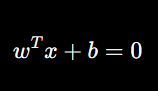

This is the decision boundary.

---

## Classification Rule

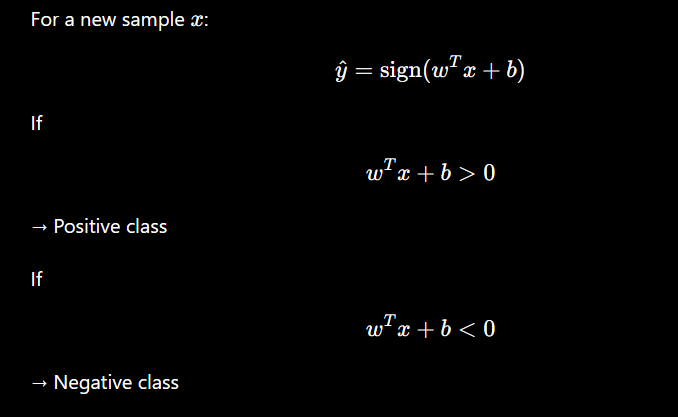

---

## Margin

The margin between the two supporting hyperplanes is

[
\boxed{\frac{2}{|w|}}
]

SVM tries to maximize this value.

---

## Optimization Objective (Hard Margin)

Instead of maximizing the margin directly, SVM solves the equivalent problem:

[
\boxed{\min \frac{1}{2}|w|^2}
]

subject to

[
\boxed{y_i(w^Tx_i+b)\ge1}
]

---

## Soft Margin Optimization

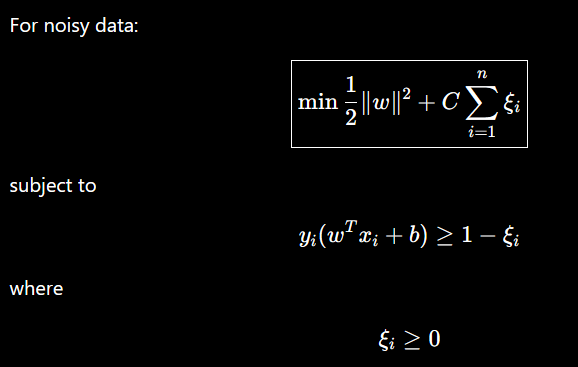

---

# 2. Meaning of Every Symbol

| Symbol   | Meaning                                                |
| -------- | ------------------------------------------------------ |
| (x)      | Feature vector                                         |
| (x_i)    | i-th training sample                                   |
| (y_i)    | Actual class label (-1 or +1)                          |
| (w)      | Weight vector (controls orientation of the hyperplane) |
| (b)      | Bias/intercept (shifts the hyperplane)                 |
| (w^Tx+b) | Decision function                                      |
| (\hat y) | Predicted class                                        |
| (|w|)    | Magnitude (length) of the weight vector                |
| (C)      | Regularization parameter                               |
| (\xi_i)  | Slack variable (amount of margin violation)            |
| (n)      | Number of training samples                             |

---

# 3. Why This Formula Works

## Step 1: Hyperplane

The equation

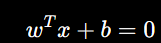

defines a separating surface.

In 2D:

```text
● ● ●

----------- Hyperplane -----------

▲ ▲ ▲
```

---

## Step 2: Supporting Hyperplanes

SVM creates two additional boundaries:

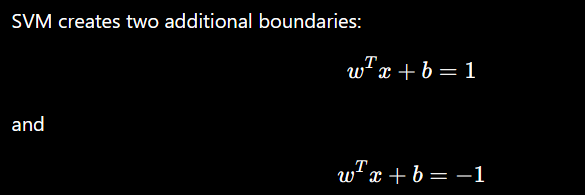

```text
● ● ●

------------------ (+1)

=========== Decision Boundary ===========

------------------ (-1)

▲ ▲ ▲
```

The nearest training samples lie on these boundaries.

These samples are the **support vectors**.

---

## Step 3: Margin

The distance between these two supporting hyperplanes is

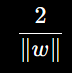

Therefore:

* Smaller (|w|)
* Larger margin

So maximizing the margin is equivalent to minimizing (|w|).

For mathematical convenience, SVM minimizes

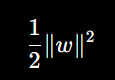

instead of just (|w|).

---

## Step 4: Why the Constraint?

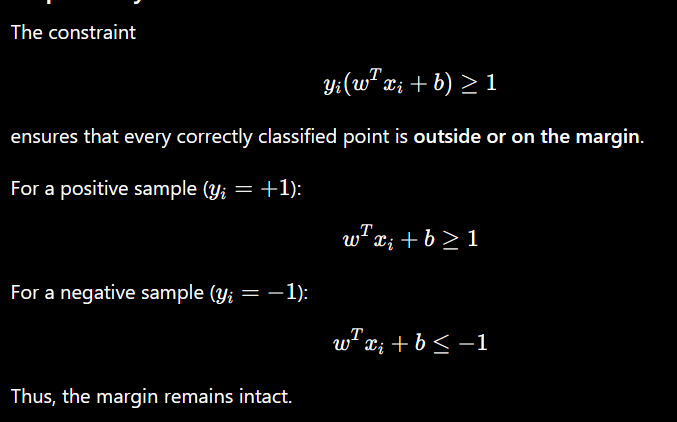

---

# 4. Geometry Intuition

Imagine many possible separating lines.

```text
Line A

● ● | ▲ ▲

Margin = Small

---------------------

Line B

● ●    |    ▲ ▲

Margin = Large

---------------------

Line C

● ●      | ▲ ▲

Margin = Medium
```

SVM always chooses **Line B**, because it has the **largest margin**.

A larger margin generally means the classifier is less sensitive to small changes or noise in the data.

---

# 5. Optimization Intuition

The optimization process can be thought of as:

```text
Training Data
      │
      ▼
Initialize Hyperplane
      │
      ▼
Measure Margin
      │
      ▼
Adjust w and b
      │
      ▼
Increase Margin
      │
      ▼
Repeat
      │
      ▼
Maximum Margin Achieved
```

> **Note:** Unlike Linear Regression or Logistic Regression, SVM is **not typically trained using gradient descent**. Most implementations solve a **convex quadratic optimization problem** (Quadratic Programming or algorithms such as SMO).

---

# 6. Hyperparameter Effect

## C (Regularization)

### Small C

* Large margin
* Allows some misclassification
* Better generalization
* Lower risk of overfitting

```text
● ●      |      ▲ ▲

Large Margin
```

---

### Large C

* Small margin
* Penalizes misclassification heavily
* Fits training data more closely
* Higher risk of overfitting

```text
● ● | ▲ ▲

Small Margin
```

---

## Kernel

Determines the shape of the decision boundary.

| Kernel     | Boundary                     |
| ---------- | ---------------------------- |
| Linear     | Straight line                |
| Polynomial | Polynomial curve             |
| RBF        | Flexible non-linear curve    |
| Sigmoid    | Neural-network-like boundary |

---

## Gamma (used with RBF, Polynomial, Sigmoid)

Controls how much influence a single training point has.

### Small Gamma

* Smooth decision boundary
* Considers points farther away
* Simpler model

```text
Smooth Curve
```

---

### Large Gamma

* Highly flexible boundary
* Considers only nearby points
* Can overfit

```text
Very Wiggly Curve
```

---

# 7. Time Complexity

Let:

* (n) = number of samples
* (d) = number of features

| Operation             | Complexity                                                           |
| --------------------- | -------------------------------------------------------------------- |
| Training (Linear SVM) | Approximately (O(nd)) to (O(n^2d)), depending on the solver and data |
| Training (Kernel SVM) | Approximately (O(n^2)) to (O(n^3))                                   |
| Prediction            | (O(s \cdot d)), where (s) is the number of support vectors           |

> Kernel SVM becomes slow on very large datasets because training depends heavily on the number of samples.

---

# 8. Space Complexity

| Operation  | Complexity                                                      |
| ---------- | --------------------------------------------------------------- |
| Linear SVM | (O(d)) for model parameters (plus training data during fitting) |
| Kernel SVM | (O(n^2)) in the worst case due to the kernel matrix             |

---

# Key Takeaways

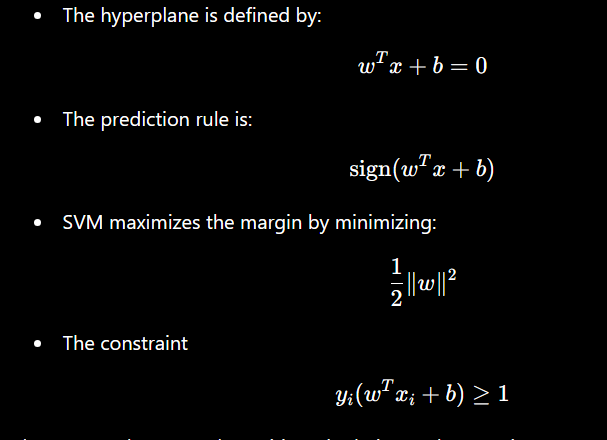

keeps samples correctly positioned relative to the margin.

* `C` controls the trade-off between **large margins** and **classification errors**.

* `gamma` controls the flexibility of non-linear decision boundaries.

* Only the **support vectors** directly determine the final decision boundary.


# **Important**

## **Understand the working of SVM perfectly**

https://chatgpt.com/share/6a62e86d-e550-83e8-a4ff-29bac1d8cc0c